<h1>Imports</h1>

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


<h1>FNN Setup</h1>

In [7]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(0.5)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return F.log_softmax(x, dim=1)

<h1>Model Init & eval<h1>

In [8]:
model = Net()
model.load_state_dict(torch.load('../models/saved_models/fnn_net.pt'))
model.eval()


Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

<h1>Transform & Load</h1>

<p>data stored native to evaluation folder</p>

In [29]:
mean = 0.1307
std = 0.3081

transformer = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((mean,), (std,))
])

testData = datasets.MNIST('./data', train=False, download=True, transform=transformer)
testLoader = DataLoader(testData, batch_size=200, shuffle=False)

data_iter = iter(testLoader)
images, labels = next(data_iter)
print(labels.unique())

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [31]:
y_true = []
y_pred = []

with torch.no_grad():
    for data, target in testLoader:
        data = data.view(data.size(0), -1)
        output = model(data)
        preds = output.argmax(dim=1, keepdim=True)
        y_true.extend(target.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"test accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_true, y_pred))

test accuracy: 10.04%
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.96      0.97       982
           5       0.96      0.96      0.96       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.95      0.94      0.94      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<h1>Confusion Matrix</h1>

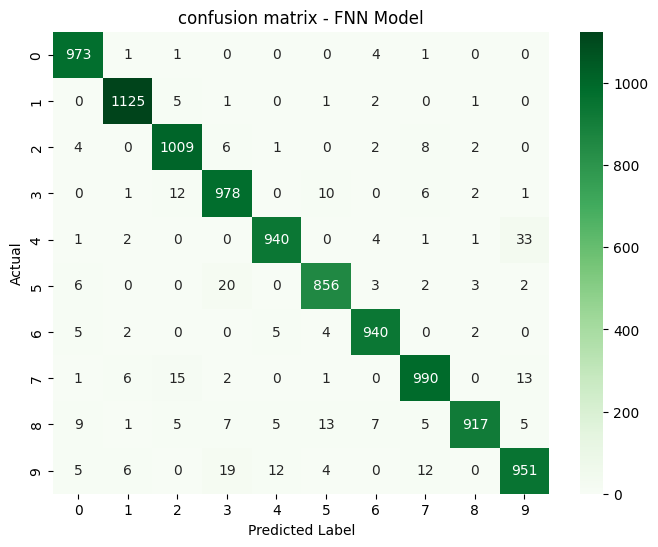

In [37]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("confusion matrix - FNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual")
plt.savefig('./figures/fnn/fnn_confusion_matrix.png')
plt.show()


<h1>Actual to Predict Plot (first 20)</h1>

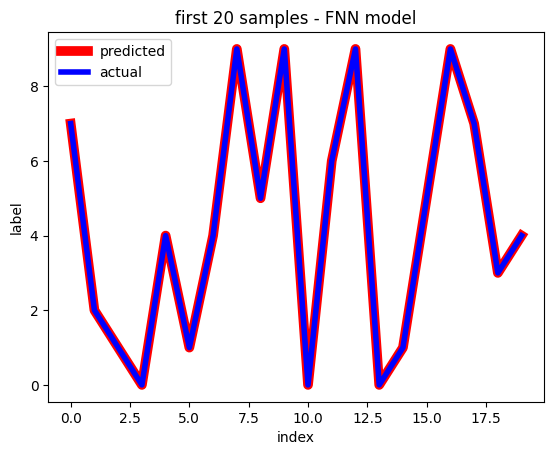

In [38]:
plt.plot(y_pred[:20], 'red', label='predicted', linewidth=7)
plt.plot(y_true[:20], 'blue', label='actual', linewidth=4)
plt.title('first 20 samples - FNN model')
plt.xlabel('index')
plt.ylabel('label')
plt.legend()
plt.savefig('./figures/fnn/fnn_pred_vs_actual.png')
plt.show()

<h1>Sample Visualisation VS Actual</h1>

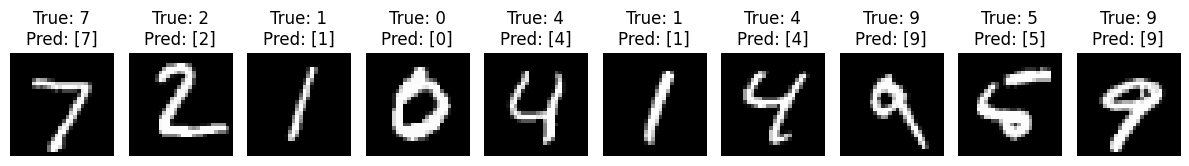

In [39]:
def sample_pred(images, true_labels, pred_labels, n=10):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray') 
        plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('./figures/fnn/fnn_sample_pred_visualisation.png')
    plt.show()

sample_pred(images, y_true, y_pred)
